# TD4 : Test d'indépendance du $\chi ^2$ entre deux variables qualitatives

Matthias Grenié, Christelle Gonindard, Margaux Leroy, Vaea Tesan et François Bettega

<div class="alert alert-info" role="alert">

## Objectifs

* Identifier quand utiliser le test du $\chi^2$ d'indépendance
* Connaître ses condititions d'application
* Savoir le mobiliser sur R
    
</div>

---

## Contexte


Ce test permet de vérifier l’absence de lien statistique entre deux variables X et Y qui sont
qualitatives.
X et Y sont dits indépendants lorsqu’il n’existe aucun lien statistique entre elles, dit autrement, la connaissance de X ne permet en aucune manière de se prononcer sur Y.

L’hypothèse nulle (H0) de ce test est la suivante : les deux variables X et Y sont indépendantes.  
L'hypothèse alternative (H1) de ce test est : les deux variables XIl est donc possible, grâce au test du $\chi ^2 $ d’indépendance, de tester le lien entre chaque paire de variables. et Y ne sont pas indépendantes.

## Méthodologie

Le fichier de données *`data_etudiant_tabac.txt`* dans le dossier *`data/`* contient les réponses de 237 étudiants de statistiques de l’Université d’Adélaïde à un trois questions. Le fichier contient trois colonnes :
1. `Fumeur` : décrit la fréquence à laquelle les étudiant⋅es fument, les valeurs sont `"Heavy"` (beaucoup), `"Regul"` (régulièrement), `"Occas"` (occasionnellement) et `"Never"` (jamais).
2. `Exercice` : décrit leur niveau d’exercice physique, les valeurs sont `"Freq"` (fréquemment), `"Some"` (un peu) et `"None"` (pas du tout).
3. `Sexe` : donne le sexe de l'étudiant⋅e `"Male"` (Homme) ou `"Female"` (Femme).

Ces trois variables sont qualitatives. 
Il est donc possible, grâce au test du $\chi ^2$ d’indépendance, de tester le lien entre chacune des variables prises deux à deux.  
**Question : existe-t-il un lien entre les habitudes tabagiques des étudiant⋅es et leur niveau d’exercice ?**


## Présentation des données

1. Lire les données

In [1]:
tabac = read.table("data/data_etudiant_tabac.txt", header = TRUE)

head(tabac)
summary(tabac)

,Fumeur,Exercice,Sexe
,<chr>,<chr>,<chr>
1,Never,Some,Female
2,Regul,None,Male
3,Occas,None,Male
4,Never,None,Male
5,Never,Some,Male
6,Never,Some,Female


    Fumeur            Exercice             Sexe          
 Length:237         Length:237         Length:237        
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  

2. Considérons les variables *`Fumeur`* et *`Exercice`* : 
    - Affichez les effectifs observés de chaque variable (avec la fonction `table()`)
    - Représentez les avec un diagramme en barre (en utilisant la fonction `barplot()`)
    - Affichez les effectifs croisés entre variables (avec la fonction `table()` en utilisant les deux colonnes comme arguments)


Heavy Never Occas Regul 
   11   190    19    17 


Freq None Some 
 115   24   98 

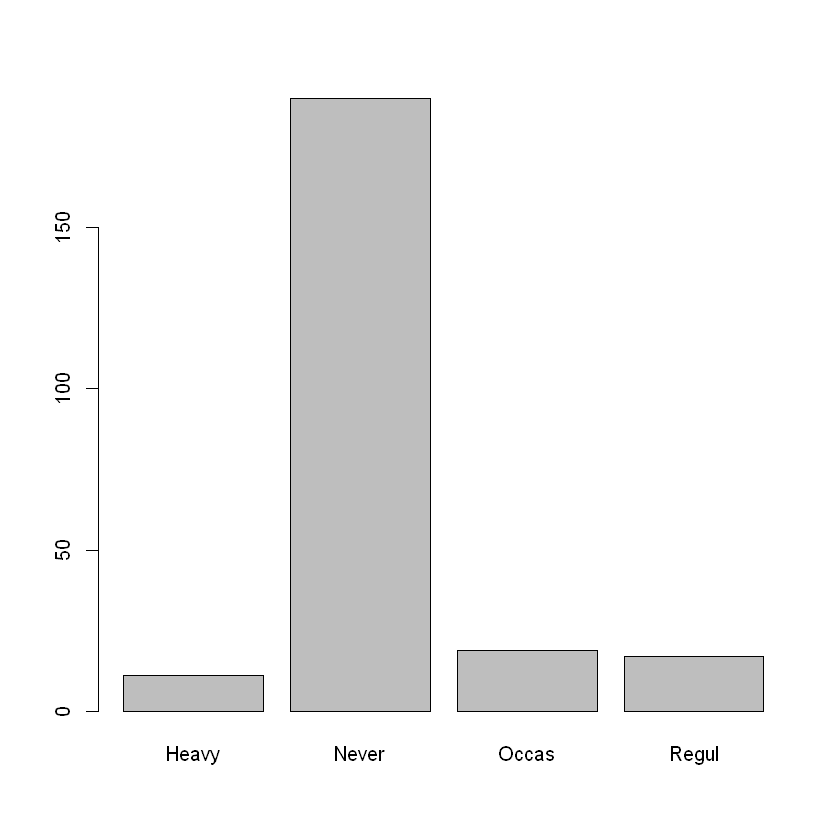

       
        Freq None Some
  Heavy    7    1    3
  Never   87   19   84
  Occas   12    3    4
  Regul    9    1    7

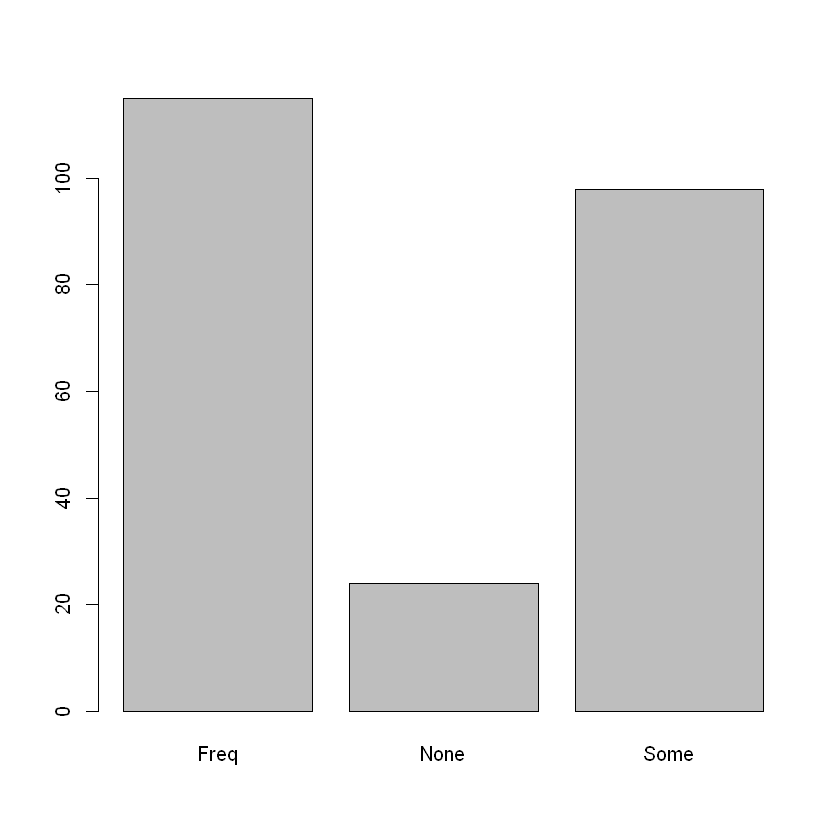

In [2]:
eff_fum = table(tabac$Fumeur)
eff_ex = table(tabac$Exercice)
eff_fum
eff_ex
barplot(eff_fum)
barplot(eff_ex)

table(tabac$Fumeur, tabac$Exercice)

**Commentaires** :

La majorité des personnes interrogées n'ont jamais fumé et font de l'exercice régulièrement. D'après le tableau de contingence entre les deux variables, il est difficile de savoir si ces variables sont indépendantes ou non.

<div class="alert alert-warning" role="alert">

## Hypothèses

H0 : Le fait de fumer est indépendant du niveau d'exercice

H1 : Le fait de fumer n'est pas indépendant du niveau d'exercice

</div>


## Vérification des conditions d'application

Pour que le test du $\chi^2$, il faut que Les **effectifs théoriques** sous H0 soient supérieurs à 5 **dans toutes les classes**, attention à ne pas les confondre avec les effectifs observés dans l'échantillon.
 
̈Pour obtenir les effectifs théoriques sans avoir à les calculer "à la main", on peut directement utiliser la fonction `chisq.test()`, qui effectue un test du $\chi^2$, et calcule, au passage les effectifs théoriques. Pour y accéder, il faut récupérer l'object `expected` (attendu en anglais) du test en faisant `chisq.test(...)$expected`.

In [3]:
# Calcul des effectifs théoriques sous H0
chisq.test(tabac$Fumeur, tabac$Exercice)$expected

Warning message in chisq.test(tabac$Fumeur, tabac$Exercice):
"L’approximation du Chi-2 est peut-être incorrecte"


,Freq,None,Some
Heavy,5.337553,1.113924,4.548523
Never,92.194093,19.240506,78.565401
Occas,9.219409,1.924051,7.856540
Regul,8.248945,1.721519,7.029536


**Interprétation** :  

On observe que la colonne `None` présente plusieurs effectifs < 5, donc on ne peut pas procéder au test du $\chi^2$

### Regroupement de valeurs

Dans ce cas, certains effectifs théoriques sont inférieurs à 5, pour réaliser un test fiable, il est
donc nécessaire de regrouper les valeurs *`"None"`* et *`"Some"`* de la colonne `Exercice`. On va créer une nouvelle colonne nommée `Exercice2` qui va transformer les valeurs `"None"` en `"Some"`.  
Pour cela on suit les étapes suivantes :
1. On commence par copier la colonne `Exercice` dans `Exercice2`, en utilisant l'expression `mon_tableau$nouvelle_colonne = mon_tableau$ancienne_colonne`.
2. Puis, on écrit l'expression pour extraire toutes les valeurs qui valent `"None"` dans `Exercice2`.
3. On ajoute l'expression `= "Some"` pour remplacer ces valeurs par `"Some"`.

In [15]:
# On remplace les "None" par des "Some"
tabac$Exercice2 = tabac$Exercice
tabac$Exercice2[tabac$Exercice2 == "None"]
tabac$Exercice2[tabac$Exercice2 == "None"] = "Some"

ERROR: Error in eval(expr, envir, enclos): objet 'tabac' introuvable


Pour vérifier qu'on a correctement transformé toutes les valeurs `"None"`, on fait un tableau de contingence de la colonne `Exercice2` (c'est le tableau qui vérifie les effectifs de la colonne `Exercice2`.

In [1]:
# Vérification
table(tabac$Exercice2)
table(tabac$Exercice2, tabac$Exercice)

ERROR: Error in eval(expr, envir, enclos): objet 'tabac' introuvable


Vérifier **à nouveau** les effectifs théoriques mais cette fois-ci, avec la nouvelle variable `Exercice2`.  
Peut-on maintenant procéder au test du $\chi^2$ ?

In [6]:
chisq.test(tabac$Fumeur, tabac$Exercice2)$expected

,Freq,Some
Heavy,5.337553,5.662447
Never,92.194093,97.805907
Occas,9.219409,9.780591
Regul,8.248945,8.751055


**Conclusion** :  
En regroupant les cas "Some" et "None" on obtient bien des effectifs théoriques supérieurs à 5 et on peut procéder au test.

## Réalisation du test 

Pour réaliser le test, on utilise la même fonction qu'au TD précédent, la fonction `chisq.test()` en utilisant les deux colonnes d'intérêts comme arguments.

In [7]:
chisq.test(tabac$Fumeur, tabac$Exercice2)


	Pearson's Chi-squared test

data:  tabac$Fumeur and tabac$Exercice2
X-squared = 3.3363, df = 3, p-value = 0.3426


**Conclusion** :  
Au seuil $\alpha = 4\%$, on a p > $\alpha$, donc on accepte H0, ce qui signifie que les variables `Fumeur` et `Exercice2` sont indépendantes.

<div class="alert alert-success" role="alert">

## Résumé

* On utilise le test du $\chi^2$ d'indépendance pour tester l'association entre deux variables qualitatives
* On le mobilise avec la fonction `chisq.test(quali1, quali2)` avec `quali1` et `quali2` les deux variables qualitatives d'intérêt
* Pour l'interpréter il faut calculer les effectifs théoriques attendus du test
* On peut les obtenir avec l'expression `chisq.test(...)$expected`, s'ils sont tous supérieurs à cinq on peut interpréter le test
* Sinon on peut regrouper les colonnes à l'aide de transformation

</div>

## Exercices d'application

### Exercice 1 : Tabagisme à l'hôpital

Le jeu de données *`tabac.txt`* dans le dossier *`data/`* contient les données d’une étude été réalisée sur 100 patients
d’un service hospitalier afin de vérifier la relation entre le tabac et les problèmes pulmonaires.
Description des colonnes :
- `ID`, l'identifiant du patient,
- `age` son âge,
- `sexe` son sexe, `homme` ou `femme`,
- `situation` sa situation maritale (`celibataire`, `en_couple`, `marie` ou `veuf`),
- `tabac` sa consommation de tabac en nombre de cigarettes par jour,
- `tabagisme_passif` la présence de tabagisme passif (`TRUE` si c'est le cas, `FALSE` sinon),
- `probleme_pulmonaire` la présence de maladie pulmonaire (cancer du poumon, BPCO, etc.) chez cette personne,
- `fumeur`, variable résumée qui définit la personne comme fumeuse si elle fume une ou plus cigarette par jour (`TRUE` si elle est fumeuse, `FALSE` sinon).

Répondez aux questions suivantes :

1. Les fumeurs ont-ils significativement plus de problèmes pulmonaires ?

In [8]:
extabac = read.table("data/tabac.txt", header = TRUE)
head(extabac)
dim(extabac)

# On va réaliser un test du chi² d'indépendance entre le fait de fumer et les problèmes pulmonaires

# Hypothèses
# H0 : Le fait de fumer est indépendant du fait d'avoir des problèmes pulmonaires
# H1 : le fait de fumer est lié au fait d'avoir des problèmes pulmonaires

# Vérification des contions d'applications
table(extabac$probleme_pulmonaire, extabac$fumeur)
chisq.test(extabac$fumeur, extabac$probleme_pulmonaire)$expected
# Tous les effectifs théoriques sont bien supérieurs à 5, donc on peut procéder au test du chi²

chisq.test(extabac$fumeur, extabac$probleme_pulmonaire)

# Au seuil alpha = 5%, on a p = 2.2⋅10⁻⁷ < alpha, donc on rejette H0, ce qui signifie
# qu'il y a une association entre le fait de fumer et les problèmes pulmonaires

,ID,age,sexe,situation,tabac,tabagisme_passif,probleme_pulmonaire,fumeur
,<int>,<int>,<chr>,<chr>,<int>,<lgl>,<lgl>,<lgl>
1,0,37,homme,marie,11,FALSE,TRUE,TRUE
2,1,23,homme,celibataire,8,FALSE,FALSE,TRUE
3,2,21,homme,veuf,0,FALSE,FALSE,FALSE
4,3,55,homme,celibataire,0,TRUE,FALSE,FALSE
5,4,61,femme,en_couple,6,FALSE,TRUE,TRUE
6,5,37,homme,marie,0,FALSE,FALSE,FALSE


[1] 100   8

       
        FALSE TRUE
  FALSE    46   19
  TRUE      5   30

,FALSE,TRUE
FALSE,33.15,17.85
TRUE,31.85,17.15



	Pearson's Chi-squared test with Yates' continuity correction

data:  extabac$fumeur and extabac$probleme_pulmonaire
X-squared = 26.828, df = 1, p-value = 2.224e-07


2. Le pourcentage de fumeur en France est de 31,8% (en 2006, chez les 15-75 ans). La répartition observée ici est-il compatible avec ce pourcentage ? Pourquoi ?

In [9]:
# Effectifs observés
eff_fumeurs = table(extabac$fumeur)

# Saisie des proportions
prop_th_fumeur = c(1 - 0.318, 0.318)

# Hypothèses
# H0 : La répartition observée est compatible avec les proportions attendues
# H1 : la répartition observée n'est pas compatible avec les proportions attendues

# Calcul effectifs théoriques
sum(eff_fumeurs) * prop_th_fumeur

# effectifs théoriques > 5, on peut réaliser le test

chisq.test(eff_fumeurs, p = prop_th_fumeur)

# Au seuil alpha = 5%, on a p = 2.2⋅10⁻⁴ < alpha, donc on rejette H0, ce qui signifie
# que la répartition n'est pas conforme aux proportions attendues
# -> il existe un biais de répartition dans notre échantillon, il y a plus de fumeurs et moins de non-fumeurs
#    que par rapport à la population française

[1] 68.2 31.8


	Chi-squared test for given probabilities

data:  eff_fumeurs
X-squared = 13.641, df = 1, p-value = 0.0002213


3. Existe-il un lien entre le tabagisme passif et les problèmes pulmonaires ?

In [10]:
# On va réaliser un test du chi² d'indépendance entre le fait de fumer et les problèmes pulmonaires

# Hypothèses
# H0 : Le fait de fumer est indépendant du fait d'avoir des problèmes pulmonaires
# H1 : le fait de fumer est lié au fait d'avoir des problèmes pulmonaires

# Vérification des conditions d'application
table(extabac$probleme_pulmonaire, extabac$tabagisme_passif)
chisq.test(extabac$tabagisme_passif, extabac$probleme_pulmonaire)$expected
# Tous les effectifs théoriques sont bien supérieurs à 5, donc on peut procéder au test du chi²

chisq.test(extabac$tabagisme_passif, extabac$probleme_pulmonaire)

# Au seuil alpha = 5%, on a p = 3.5⋅10⁻³ < alpha, donc on rejette H0, ce qui signifie
# qu'il y a une association entre le tabagisme passif et les problèmes pulmonaires

       
        FALSE TRUE
  FALSE    49   16
  TRUE     35    0

,FALSE,TRUE
FALSE,54.6,29.4
TRUE,10.4,5.6



	Pearson's Chi-squared test with Yates' continuity correction

data:  extabac$tabagisme_passif and extabac$probleme_pulmonaire
X-squared = 8.5067, df = 1, p-value = 0.003538


### Exercice 2 : Résistance bactérienne

Vous travaillez dans un laboratoire de microbiologie clinique. Vous analysez 300 prélèvements d'infections urinaires pour identifier l'espèce bactérienne responsable et tester sa sensibilité à un antibiotique de première ligne (la ciprofloxacine). Vous voulez savoir si la résistance à l'antibiotique dépend de l'espèce bactérienne.

In [5]:
# Données
donnees_resistance = matrix(
  c(85, 15,    # E. coli
    45, 35,    # K. pneumoniae
    55, 15,    # P. mirabilis
    30, 20),   # Enterococcus
  nrow = 4,
  byrow = TRUE,
  dimnames = list(
    Espèce = c("E. coli", "K. pneumoniae", "P. mirabilis", "Enterococcus"),
    Sensibilité = c("Sensible", "Résistant")
  )
)

donnees_resistance

,Sensible,Résistant
E. coli,85,15
K. pneumoniae,45,35
P. mirabilis,55,15
Enterococcus,30,20


1. Calculez le nombre total de prélèvements observés avec la fonction `sum()`.

In [6]:
sum(donnees_resistance)

[1] 300

2. Calculez la proportion de bactéries résistantes par espèce (_indice : vous pouvez vous servir de la fonction `rowSums()` pour calculer les effectifs totaux par espèce_). Quelle espèce est la plus résistante ? Et laquelle est la moins résistante ?

In [9]:
donnees_resistance[, "Résistant"]/rowSums(donnees_resistance)
# => Plus résistante = K. pneumoniae, moins résistante = E. coli

E. coli K. pneumoniae  P. mirabilis  Enterococcus 
    0.1500000     0.4375000     0.2142857     0.4000000

3. Est-ce que la résistance à la ciproflaxine est liée à l'espèce ?

In [12]:
rest = chisq.test(donnees_resistance)

rest$expected
rest

# => On observe p = 3,8⋅10⁻⁵ <<< 0,05, donc on rejette H0 et cela signifie qu'il y a une association entre l'espèce et la résistance à la ciproflaxine.

,Sensible,Résistant
E. coli,71.66667,28.33333
K. pneumoniae,57.33333,22.66667
P. mirabilis,50.16667,19.83333
Enterococcus,35.83333,14.16667



	Pearson's Chi-squared test

data:  donnees_resistance
X-squared = 23.114, df = 3, p-value = 3.823e-05


4. Étudiez les résidus du test avec `$residuals`, pour identifier les espèces qui sont plus sensibles et plus résistantes qu'attendus.

In [13]:
rest$residuals
# ==> E. coli est la moins résistante qu'attendue par hasard, et K. pneumoniae la plus résistante qu'attendue par hasard.

,Sensible,Résistant
E. coli,1.5749985,-2.504897
K. pneumoniae,-1.6288342,2.590518
P. mirabilis,0.6824002,-1.085298
Enterococcus,-0.9744806,1.549826
